In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from dataclasses import dataclass
from typing import List, Tuple, Optional
import gym
from gym import spaces

In [2]:
# Configuración del entorno 3D
@dataclass
class RobotArm3DConfig:
    """Configuración del brazo robótico 3D"""
    num_joints: int = 4  # Base (yaw) + 3 articulaciones
    workspace_radius: float = 1.0  # Radio del espacio de trabajo
    workspace_height: float = 0.8  # Altura máxima
    max_steps: int = 100  # Más pasos para movimiento 3D
    cup_radius: float = 0.05
    cup_height: float = 0.08
    success_threshold: float = 0.1

In [3]:
class RobotArm3DEnv(gym.Env):
    """Entorno 3D del brazo robótico"""
    
    def __init__(self, config: RobotArm3DConfig):
        super().__init__()
        self.config = config
        
        # Espacios de acción y observación
        self.action_space = spaces.Box(
            low=-1.0, high=1.0,
            shape=(config.num_joints,), dtype=np.float32
        )
        
        # Estado: posición vaso (x,y,z), ángulos articulaciones, posición efector (x,y,z)
        # Total: 3 + num_joints + 3 = 10 dimensiones para 4 joints
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(3 + config.num_joints + 3,), dtype=np.float32
        )
        
        # Longitudes de los links
        self.link_lengths = [0.0, 0.3, 0.25, 0.2]  # Base, link1, link2, link3
        
        self.reset()
    
    def reset(self):
        """Reinicia el entorno en 3D"""
        # Posición aleatoria del vaso en 3D
        # Usar coordenadas cilíndricas para mejor distribución
        angle = np.random.uniform(0, 2*np.pi)
        radius = np.random.uniform(0.3, self.config.workspace_radius * 0.8)
        height = np.random.uniform(0.0, self.config.workspace_height * 0.6)
        
        self.cup_position = np.array([
            radius * np.cos(angle),
            radius * np.sin(angle),
            height
        ])
        
        # Ángulos iniciales: [base_yaw, joint1, joint2, joint3]
        self.joint_angles = np.array([0.0, 0.0, 0.0, 0.0])
        
        # Calcular posición del efector final
        self.end_effector_pos = self._forward_kinematics_3d(self.joint_angles)
        
        self.steps = 0
        self.episode_reward = 0
        self.previous_distance = np.linalg.norm(self.end_effector_pos - self.cup_position)
        
        return self._get_observation()
    
    def _forward_kinematics_3d(self, angles):
        """Cinemática directa 3D del brazo"""
        base_yaw = angles[0]  # Rotación de la base
        joint_angles = angles[1:]  # Ángulos de las articulaciones
        
        # Posición inicial en la base
        x, y, z = 0, 0, 0.1  # Base elevada 0.1m
        
        # Rotación acumulada en el plano vertical
        cumulative_pitch = 0
        
        # Para cada articulación
        for i, (angle, length) in enumerate(zip(joint_angles, self.link_lengths[1:])):
            cumulative_pitch += angle
            
            # Proyección en el plano XY considerando yaw de la base
            dx = length * np.cos(cumulative_pitch) * np.cos(base_yaw)
            dy = length * np.cos(cumulative_pitch) * np.sin(base_yaw)
            dz = length * np.sin(cumulative_pitch)
            
            x += dx
            y += dy
            z += dz
        
        return np.array([x, y, z])
    
    def _get_observation(self):
        """Obtiene el estado actual del sistema 3D"""
        return np.concatenate([
            self.cup_position,      # 3D
            self.joint_angles,      # 4 ángulos
            self.end_effector_pos   # 3D
        ])
    
    def step(self, action):
        """Ejecuta una acción en el entorno 3D"""
        # Aplicar acción con diferentes escalas para cada joint
        action_scales = [0.15, 0.1, 0.1, 0.1]  # Base gira más rápido
        for i in range(self.config.num_joints):
            self.joint_angles[i] += action[i] * action_scales[i]
        
        # Límites de los joints
        joint_limits = [
            (-np.pi, np.pi),      # Base: rotación completa
            (-np.pi/2, np.pi/2),  # Joint 1: -90° a 90°
            (-np.pi/2, np.pi/2),  # Joint 2: -90° a 90°
            (-np.pi/3, np.pi/3),  # Joint 3: -60° a 60°
        ]
        
        for i, (low, high) in enumerate(joint_limits):
            self.joint_angles[i] = np.clip(self.joint_angles[i], low, high)
        
        # Actualizar posición del efector
        self.end_effector_pos = self._forward_kinematics_3d(self.joint_angles)
        
        # Calcular distancia 3D
        distance = np.linalg.norm(self.end_effector_pos - self.cup_position)
        
        # Sistema de recompensas mejorado para 3D
        reward = -distance
        
        # Recompensa por progreso
        progress = self.previous_distance - distance
        reward += progress * 3.0
        self.previous_distance = distance
        
        # Recompensa por altura similar al vaso
        height_diff = abs(self.end_effector_pos[2] - self.cup_position[2])
        if height_diff < 0.1:
            reward += 1.0
        
        # Bonus por cercanía
        if distance < self.config.cup_radius * 3:
            reward += 2.0
        if distance < self.config.cup_radius * 2:
            reward += 3.0
        
        # Éxito si toca el vaso
        if distance < self.config.cup_radius:
            reward += 20.0  # Mayor recompensa en 3D
            done = True
        else:
            done = False
        
        # Penalización por salir del espacio de trabajo
        if self.end_effector_pos[2] < 0 or self.end_effector_pos[2] > self.config.workspace_height:
            reward -= 2.0
        
        self.steps += 1
        if self.steps >= self.config.max_steps:
            done = True
            reward -= 5.0
        
        self.episode_reward += reward
        
        info = {
            'distance': distance,
            'end_effector_pos': self.end_effector_pos,
            'cup_position': self.cup_position
        }
        
        return self._get_observation(), reward, done, info


In [4]:
# Red neuronal mejorada para 3D
class PolicyNetwork3D(nn.Module):
    """Red neuronal para política 3D"""
    
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # Red más profunda para complejidad 3D
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc4 = nn.Linear(hidden_size // 2, output_size)
        
        self.log_std = nn.Parameter(torch.zeros(output_size))
        
        # Batch normalization para estabilidad
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        
    def forward(self, x):
        # Manejar tanto batch como single input
        if len(x.shape) == 1:
            x = x.unsqueeze(0)
            batch_mode = False
        else:
            batch_mode = True
            
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.fc3(x))
        mean = torch.tanh(self.fc4(x))
        std = torch.exp(self.log_std.clamp(-2, 2))  # Limitar std
        
        if not batch_mode:
            mean = mean.squeeze(0)
            
        return mean, std


In [5]:
# Visualizador 3D del brazo
class RobotArm3DVisualizer:
    """Visualiza el brazo robótico en 3D"""
    
    def __init__(self, env):
        self.env = env
        self.fig = plt.figure(figsize=(10, 8))
        self.ax = self.fig.add_subplot(111, projection='3d')
        
    def plot_state(self, save_path=None):
        """Dibuja el estado actual del brazo y el vaso"""
        self.ax.clear()
        
        # Calcular posiciones de todas las articulaciones
        positions = self._get_joint_positions()
        
        # Dibujar links
        for i in range(len(positions) - 1):
            self.ax.plot3D(
                [positions[i][0], positions[i+1][0]],
                [positions[i][1], positions[i+1][1]],
                [positions[i][2], positions[i+1][2]],
                'b-', linewidth=3
            )
        
        # Dibujar articulaciones
        for pos in positions:
            self.ax.scatter(*pos, color='red', s=50)
        
        # Dibujar efector final
        self.ax.scatter(*positions[-1], color='green', s=100, marker='o')
        
        # Dibujar vaso
        self.ax.scatter(*self.env.cup_position, color='orange', s=200, marker='v')
        
        # Dibujar cilindro del vaso (aproximación)
        self._draw_cylinder(
            self.env.cup_position,
            self.env.config.cup_radius,
            self.env.config.cup_height
        )
        
        # Configurar ejes
        self.ax.set_xlim([-1, 1])
        self.ax.set_ylim([-1, 1])
        self.ax.set_zlim([0, 1])
        self.ax.set_xlabel('X')
        self.ax.set_ylabel('Y')
        self.ax.set_zlabel('Z')
        self.ax.set_title('Brazo Robótico 3D')
        
        if save_path:
            plt.savefig(save_path)
        else:
            plt.pause(0.01)
    
    def _get_joint_positions(self):
        """Calcula las posiciones de todas las articulaciones"""
        positions = [[0, 0, 0.1]]  # Base
        
        base_yaw = self.env.joint_angles[0]
        joint_angles = self.env.joint_angles[1:]
        
        x, y, z = 0, 0, 0.1
        cumulative_pitch = 0
        
        for i, (angle, length) in enumerate(zip(joint_angles, self.env.link_lengths[1:])):
            cumulative_pitch += angle
            
            dx = length * np.cos(cumulative_pitch) * np.cos(base_yaw)
            dy = length * np.cos(cumulative_pitch) * np.sin(base_yaw)
            dz = length * np.sin(cumulative_pitch)
            
            x += dx
            y += dy
            z += dz
            
            positions.append([x, y, z])
        
        return positions
    
    def _draw_cylinder(self, center, radius, height):
        """Dibuja un cilindro (vaso)"""
        z = np.linspace(center[2], center[2] + height, 10)
        theta = np.linspace(0, 2*np.pi, 20)
        theta_grid, z_grid = np.meshgrid(theta, z)
        
        x_grid = center[0] + radius * np.cos(theta_grid)
        y_grid = center[1] + radius * np.sin(theta_grid)
        
        self.ax.plot_surface(x_grid, y_grid, z_grid, alpha=0.3, color='orange')


In [6]:
# Sistema de entrenamiento adaptado para 3D
class RobotArm3DTrainer:
    """Entrenador para el brazo robótico 3D"""
    
    def __init__(self):
        self.config = RobotArm3DConfig()
        self.env = RobotArm3DEnv(self.config)
        
        # Usar la red 3D
        state_dim = self.env.observation_space.shape[0]
        action_dim = self.env.action_space.shape[0]
        
        self.agent = PPOAgent3D(state_dim, action_dim)
        self.curriculum = CurriculumManager3D()
        self.imitation = ImitationLearning3D(self.agent, self.env)
        
        # Visualizador
        self.visualizer = RobotArm3DVisualizer(self.env)
        
        # Métricas
        self.episode_rewards = []
        self.success_rates = []
        self.distances = []
    
    def train(self, num_episodes=2000, visualize_every=100):
        """Entrena el agente en el entorno 3D"""
        
        # Fase 1: Aprendizaje por imitación
        print("=== Fase 1: Aprendizaje por Imitación 3D ===")
        self.imitation.generate_expert_demonstrations_3d(num_demos=300)
        self.imitation.pretrain_3d(epochs=100)
        
        # Fase 2: Entrenamiento con RL
        print("\n=== Fase 2: Entrenamiento con PPO en 3D ===")
        
        for episode in range(num_episodes):
            # Ajustar dificultad
            task_params = self.curriculum.get_task_params()
            self.env.config.workspace_radius = task_params['workspace_radius']
            self.env.config.workspace_height = task_params['workspace_height']
            
            state = self.env.reset()
            episode_reward = 0
            episode_distances = []
            
            while True:
                action, log_prob = self.agent.get_action(state)
                next_state, reward, done, info = self.env.step(action)
                
                self.agent.store_transition(state, action, reward, log_prob, done)
                
                episode_reward += reward
                episode_distances.append(info['distance'])
                state = next_state
                
                if done:
                    success = info['distance'] < self.config.cup_radius
                    break
            
            self.episode_rewards.append(episode_reward)
            self.distances.append(min(episode_distances))
            
            # Visualizar progreso
            if episode % visualize_every == 0 and episode > 0:
                self.visualizer.plot_state()
                plt.show()
            
            # Entrenar cada 20 episodios
            if (episode + 1) % 20 == 0:
                self.agent.train()
                
                # Calcular métricas
                recent_rewards = self.episode_rewards[-100:]
                recent_distances = self.distances[-100:]
                success_rate = sum([d < self.config.cup_radius for d in recent_distances]) / len(recent_distances)
                
                self.success_rates.append(success_rate)
                self.curriculum.update_difficulty(success_rate)
                
                print(f"Episode {episode+1}, Avg Reward: {np.mean(recent_rewards):.2f}, "
                      f"Success Rate: {success_rate*100:.1f}%, "
                      f"Avg Distance: {np.mean(recent_distances):.3f}, "
                      f"Difficulty: {self.curriculum.current_difficulty:.2f}")

In [7]:
# Agente PPO adaptado para 3D
class PPOAgent3D:
    """Agente PPO para el brazo 3D"""
    
    def __init__(self, state_dim, action_dim, lr=3e-4):
        self.policy = PolicyNetwork3D(state_dim, 256, action_dim)  # Red más grande
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.gamma = 0.99
        self.eps_clip = 0.2
        self.k_epochs = 6  # Más épocas para 3D
        
        # Buffers
        self.states = []
        self.actions = []
        self.rewards = []
        self.log_probs = []
        self.dones = []
        
 
    def get_action(self, state):
        """Obtiene acción para estado 3D"""
        state = torch.FloatTensor(state)
        was_training = self.policy.training
        if len(state.shape) == 1:
            self.policy.eval()  # Cambia a modo evaluación para evitar error de BatchNorm
        mean, std = self.policy(state)
        if len(state.shape) == 1 and was_training:
            self.policy.train()  # Devuelve al modo anterior si era entrenamiento
        dist = torch.distributions.Normal(mean, std)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum()
        return action.numpy(), log_prob

    
    def store_transition(self, state, action, reward, log_prob, done):
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)
        self.log_probs.append(log_prob)
        self.dones.append(done)
    
    def train(self):
        """Entrena con PPO"""
        # Calcular retornos
        returns = []
        discounted_reward = 0
        for reward, done in zip(reversed(self.rewards), reversed(self.dones)):
            if done:
                discounted_reward = 0
            discounted_reward = reward + self.gamma * discounted_reward
            returns.insert(0, discounted_reward)
        
        # Normalizar
        returns = torch.tensor(returns, dtype=torch.float32)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        
        # Convertir a tensores
        states = torch.tensor(np.array(self.states), dtype=torch.float32)
        actions = torch.tensor(np.array(self.actions), dtype=torch.float32)
        old_log_probs = torch.tensor(self.log_probs, dtype=torch.float32)
        
        # Optimización PPO
        for _ in range(self.k_epochs):
            mean, std = self.policy(states)
            dist = torch.distributions.Normal(mean, std)
            new_log_probs = dist.log_prob(actions).sum(dim=1)
            
            ratio = torch.exp(new_log_probs - old_log_probs)
            
            surr1 = ratio * returns
            surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * returns
            
            loss = -torch.min(surr1, surr2).mean()
            
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 0.5)
            self.optimizer.step()
        
        # Limpiar buffers
        self.states.clear()
        self.actions.clear()
        self.rewards.clear()
        self.log_probs.clear()
        self.dones.clear()

In [8]:
# Curriculum Learning para 3D
class CurriculumManager3D:
    """Gestiona el curriculum para el espacio 3D"""
    
    def __init__(self):
        self.current_difficulty = 0.3
        self.max_difficulty = 1.0
        self.success_history = deque(maxlen=100)
        
    def update_difficulty(self, success_rate):
        """Actualiza dificultad para 3D"""
        self.success_history.append(success_rate)
        
        if len(self.success_history) >= 20:
            avg_success = np.mean(list(self.success_history)[-20:])
            
            if avg_success > 0.75:
                self.current_difficulty = min(
                    self.current_difficulty * 1.1,
                    self.max_difficulty
                )
            elif avg_success < 0.4:
                self.current_difficulty = max(
                    self.current_difficulty * 0.9,
                    0.2
                )
    
    def get_task_params(self):
        """Parámetros según dificultad"""
        return {
            'workspace_radius': 0.3 + self.current_difficulty * 0.7,
            'workspace_height': 0.3 + self.current_difficulty * 0.5
        }

In [9]:
# Aprendizaje por imitación 3D
class ImitationLearning3D:
    """Sistema de imitación para 3D"""
    
    def __init__(self, agent, env):
        self.agent = agent
        self.env = env
        self.demonstrations = []
    
    def generate_expert_demonstrations_3d(self, num_demos=200):
        """Genera demos expertas en 3D"""
        print("Generando demostraciones expertas 3D...")
        
        for demo_idx in range(num_demos):
            state = self.env.reset()
            trajectory = []
            
            for _ in range(self.env.config.max_steps):
                # Controlador experto 3D
                cup_pos = state[:3]
                ee_pos = state[-3:]
                joint_angles = state[3:7]
                
                # Calcular error en 3D
                error_3d = cup_pos - ee_pos
                
                # Control proporcional para cada joint
                action = np.zeros(4)
                
                # Control de yaw (base)
                target_yaw = np.arctan2(cup_pos[1], cup_pos[0])
                action[0] = np.clip(target_yaw - joint_angles[0], -1, 1)
                
                # Control de pitch para altura
                distance_xy = np.sqrt(error_3d[0]**2 + error_3d[1]**2)
                target_pitch = np.arctan2(error_3d[2], distance_xy)
                
                # Distribuir el pitch entre los joints
                action[1] = np.clip(target_pitch * 0.5, -1, 1)
                action[2] = np.clip(target_pitch * 0.3, -1, 1)
                action[3] = np.clip(target_pitch * 0.2, -1, 1)
                
                # Añadir ruido
                action += np.random.normal(0, 0.05, size=4)
                action = np.clip(action, -1, 1)
                
                next_state, reward, done, _ = self.env.step(action)
                trajectory.append((state, action, reward))
                
                state = next_state
                if done and reward > 15:  # Solo demos exitosas
                    self.demonstrations.append(trajectory)
                    break
            
            if (demo_idx + 1) % 50 == 0:
                print(f"Generadas {len(self.demonstrations)} demos exitosas de {demo_idx + 1} intentos")
        
        print(f"Total demos exitosas: {len(self.demonstrations)}")
    
    def pretrain_3d(self, epochs=100):
        """Preentrenamiento para 3D"""
        if not self.demonstrations:
            print("No hay demostraciones para entrenar")
            return
            
        print("Preentrenando con behavior cloning 3D...")
        
        # Preparar datos
        states = []
        actions = []
        
        for demo in self.demonstrations:
            for state, action, _ in demo:
                states.append(state)
                actions.append(action)
        
        states = torch.tensor(states, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.float32)
        
        # Entrenar
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.agent.policy.parameters(), lr=1e-3)
        
        dataset = torch.utils.data.TensorDataset(states, actions)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
        
        for epoch in range(epochs):
            total_loss = 0
            for batch_states, batch_actions in dataloader:
                mean, _ = self.agent.policy(batch_states)
                loss = criterion(mean, batch_actions)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
            
            if epoch % 20 == 0:
                print(f"Epoch {epoch}, Loss: {total_loss/len(dataloader):.4f}")


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
import torch
from scipy.spatial.transform import Rotation
import trimesh
import time

class AdvancedRobotVisualizer3D:
    """Visualizador avanzado con animación fluida y realista"""
    
    def __init__(self, link_lengths=[0.2, 0.3, 0.25, 0.2]):
        self.link_lengths = link_lengths
        self.fig = plt.figure(figsize=(12, 10))
        self.ax = self.fig.add_subplot(111, projection='3d')
        
        # Configuración visual mejorada
        self.ax.set_facecolor('white')
        self.fig.patch.set_facecolor('white')
        
        # Historia de posiciones para trazar trayectoria
        self.trajectory_history = []
        self.max_history = 50
        
    def plot_robot_state(self, joint_angles, cup_position, end_effector_pos=None, 
                        show_trajectory=True, title="Brazo Robótico 3D"):
        """Visualiza el estado del robot con mejoras visuales"""
        self.ax.clear()
        
        # Calcular posiciones de todas las articulaciones
        positions = self._calculate_joint_positions_3d(joint_angles)
        
        # Dibujar base elevada
        base_height = 0.2
        self._draw_base(base_height)
        
        # Dibujar links con grosor variable
        link_widths = [8, 6, 5, 4]
        link_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
        
        for i in range(len(positions) - 1):
            # Links como cilindros 3D
            self._draw_cylinder_link(
                positions[i], positions[i+1], 
                width=link_widths[i], 
                color=link_colors[i]
            )
        
        # Dibujar articulaciones como esferas
        joint_sizes = [150, 120, 100, 80]
        for i, pos in enumerate(positions[:-1]):
            self.ax.scatter(*pos, s=joint_sizes[i], c='darkgray', 
                          edgecolors='black', linewidth=2, alpha=0.9)
        
        # Dibujar efector final especial
        ee_pos = positions[-1]
        self.ax.scatter(*ee_pos, s=200, c='green', marker='*', 
                       edgecolors='darkgreen', linewidth=2)
        
        # Añadir a la historia de trayectoria
        if show_trajectory:
            self.trajectory_history.append(ee_pos)
            if len(self.trajectory_history) > self.max_history:
                self.trajectory_history.pop(0)
            
            # Dibujar trayectoria con gradiente
            if len(self.trajectory_history) > 1:
                for i in range(1, len(self.trajectory_history)):
                    alpha = i / len(self.trajectory_history)
                    self.ax.plot3D(
                        [self.trajectory_history[i-1][0], self.trajectory_history[i][0]],
                        [self.trajectory_history[i-1][1], self.trajectory_history[i][1]],
                        [self.trajectory_history[i-1][2], self.trajectory_history[i][2]],
                        'g-', alpha=alpha*0.5, linewidth=2
                    )
        
        # Dibujar vaso mejorado
        self._draw_cup_3d(cup_position, radius=0.05, height=0.1)
        
        # Dibujar línea de objetivo
        self.ax.plot3D(
            [ee_pos[0], cup_position[0]],
            [ee_pos[1], cup_position[1]],
            [ee_pos[2], cup_position[2]],
            'k--', alpha=0.3, linewidth=1
        )
        
        # Mostrar distancia
        distance = np.linalg.norm(np.array(ee_pos) - np.array(cup_position))
        self.ax.text2D(0.05, 0.95, f'Distancia: {distance:.3f}m', 
                      transform=self.ax.transAxes, fontsize=12)
        
        # Configurar ejes
        self._setup_axes()
        self.ax.set_title(title, fontsize=14, fontweight='bold')
        
        plt.draw()
        
    def _calculate_joint_positions_3d(self, joint_angles):
        """Calcula las posiciones 3D de todas las articulaciones"""
        positions = []
        
        # Base elevada
        base_height = 0.2
        x, y, z = 0, 0, base_height
        positions.append([x, y, z])
        
        # Rotación de la base (yaw)
        base_yaw = joint_angles[0]
        
        # Articulaciones con rotación pitch
        cumulative_pitch = 0
        for i, (angle, length) in enumerate(zip(joint_angles[1:], self.link_lengths)):
            cumulative_pitch += angle
            
            # Calcular nueva posición considerando yaw y pitch
            dx = length * np.cos(cumulative_pitch) * np.cos(base_yaw)
            dy = length * np.cos(cumulative_pitch) * np.sin(base_yaw)
            dz = length * np.sin(cumulative_pitch)
            
            x += dx
            y += dy
            z += dz
            
            positions.append([x, y, z])
        
        return positions
    
    def _draw_base(self, height):
        """Dibuja la base del robot"""
        # Cilindro para la base
        u = np.linspace(0, 2 * np.pi, 30)
        v = np.linspace(0, height, 2)
        x = 0.15 * np.outer(np.cos(u), np.ones(np.size(v)))
        y = 0.15 * np.outer(np.sin(u), np.ones(np.size(v)))
        z = np.outer(np.ones(np.size(u)), v)
        
        self.ax.plot_surface(x, y, z, color='darkblue', alpha=0.8)
    
    def _draw_cylinder_link(self, start, end, width=5, color='blue'):
        """Dibuja un link como línea gruesa"""
        self.ax.plot3D(
            [start[0], end[0]],
            [start[1], end[1]],
            [start[2], end[2]],
            color=color, linewidth=width, solid_capstyle='round'
        )
    
    def _draw_cup_3d(self, position, radius=0.05, height=0.1):
        """Dibuja un vaso 3D mejorado"""
        # Cilindro para el vaso
        u = np.linspace(0, 2 * np.pi, 20)
        v = np.linspace(0, height, 10)
        x = radius * np.outer(np.cos(u), np.ones(np.size(v))) + position[0]
        y = radius * np.outer(np.sin(u), np.ones(np.size(v))) + position[1]
        z = np.outer(np.ones(np.size(u)), v) + position[2]
        
        self.ax.plot_surface(x, y, z, color='orange', alpha=0.7, 
                           edgecolor='darkorange', linewidth=0.5)
        
        # Tapa del vaso
        self.ax.scatter(*position, s=100, c='red', marker='v')
    
    def _setup_axes(self):
        """Configura los ejes para mejor visualización"""
        self.ax.set_xlim([-0.8, 0.8])
        self.ax.set_ylim([-0.8, 0.8])
        self.ax.set_zlim([0, 1.0])
        
        self.ax.set_xlabel('X (m)', fontsize=10)
        self.ax.set_ylabel('Y (m)', fontsize=10)
        self.ax.set_zlabel('Z (m)', fontsize=10)
        
        # Grid mejorado
        self.ax.grid(True, alpha=0.3)
        self.ax.xaxis.pane.fill = False
        self.ax.yaxis.pane.fill = False
        self.ax.zaxis.pane.fill = False
        
        # Vista isométrica
        self.ax.view_init(elev=25, azim=45)

In [11]:
# Función principal
def main():
    """Ejecuta el entrenamiento 3D"""
    print("=== Sistema de Brazo Robótico 3D ===")
    
    trainer = RobotArm3DTrainer()
    trainer.train(num_episodes=3000, visualize_every=500)
    
    # Evaluación final
    print("\n=== Evaluación Final 3D ===")
    successes = 0
    trainer.env.config.workspace_radius = 1.0  # Máxima dificultad
    trainer.env.config.workspace_height = 0.8
    
    for _ in range(100):
        state = trainer.env.reset()
        done = False
        
        while not done:
            action, _ = trainer.agent.get_action(state)
            state, _, done, info = trainer.env.step(action)
            
            if done and info['distance'] < trainer.config.cup_radius:
                successes += 1
    
    print(f"Tasa de éxito final en 3D: {successes}%")
    
    # Visualizar un episodio final
    print("\nVisualizando episodio final (animado)...")
    state = trainer.env.reset()
    visualizer = AdvancedRobotVisualizer3D(link_lengths=trainer.env.link_lengths[1:])  # Usa tus links reales
    done = False
    step = 0
    
    while not done and step < 100:
        joint_angles = state[3:7]
        cup_pos = state[:3]
        ee_pos = state[-3:]
        visualizer.plot_robot_state(joint_angles, cup_pos, end_effector_pos=ee_pos, 
                                   title=f"Simulación animada - Paso {step}")
        plt.pause(0.08)
        action, _ = trainer.agent.get_action(state)
        state, _, done, _ = trainer.env.step(action)
        step += 1

    plt.show()

    def evaluate_with_matplotlib(trainer, render, num_episodes):
        """Evaluación con visualización matplotlib avanzada"""

        visualizer = AdvancedRobotVisualizer3D()
        successes = 0

        # Configurar para dificultad máxima
        trainer.env.config.workspace_radius = 1.0
        trainer.env.config.workspace_height = 0.8

        for episode in range(num_episodes):
            print(f"\n🎯 Episodio {episode + 1}/{num_episodes}")

            # Reset entorno
            state = trainer.env.reset()
            done = False
            steps = 0

            # Limpiar historia de trayectoria
            visualizer.trajectory_history = []

            # Extraer información inicial
            cup_pos = state[:3]
            joint_angles = state[3:7]

            print(f"  Vaso en: ({cup_pos[0]:.2f}, {cup_pos[1]:.2f}, {cup_pos[2]:.2f})")

            # Visualización inicial
            if render:
                visualizer.plot_robot_state(
                    joint_angles, cup_pos,
                    title=f"Episodio {episode + 1} - Inicio"
                )
                plt.pause(0.5)

            while not done and steps < 100:
                # Obtener acción
                with torch.no_grad():
                    action, _ = trainer.agent.get_action(state)

                # Ejecutar acción
                next_state, reward, done, info = trainer.env.step(action)

                # Visualizar cada N pasos
                if render and steps % 5 == 0:
                    joint_angles = next_state[3:7]
                    cup_pos = next_state[:3]

                    visualizer.plot_robot_state(
                        joint_angles, cup_pos,
                        title=f"Episodio {episode + 1} - Paso {steps}"
                    )
                    plt.pause(0.05)

                state = next_state
                steps += 1

                # Verificar éxito
                if done and info['distance'] < trainer.config.cup_radius:
                    successes += 1
                    print(f"  ✅ ¡Éxito! Distancia final: {info['distance']:.3f}m")

                    if render:
                        visualizer.plot_robot_state(
                            joint_angles, cup_pos,
                            title=f"Episodio {episode + 1} - ¡ÉXITO!"
                        )
                        plt.pause(1.0)
                    break
                
            if not (done and info['distance'] < trainer.config.cup_radius):
                print(f"  ❌ Fallo. Distancia final: {info['distance']:.3f}m")

                if render:
                    visualizer.plot_robot_state(
                        joint_angles, cup_pos,
                        title=f"Episodio {episode + 1} - Fallo"
                    )
                    plt.pause(0.5)

        success_rate = successes / num_episodes
        print(f"\n📊 Tasa de éxito final: {success_rate*100:.1f}%")
    
        # Mostrar resumen visual
        if render:
            plt.figure(figsize=(10, 6))
            episodes = list(range(1, num_episodes + 1))
            results = ['Éxito' if i < successes else 'Fallo' for i in range(num_episodes)]
            colors = ['green' if r == 'Éxito' else 'red' for r in results]

            plt.bar(episodes, [1]*num_episodes, color=colors, alpha=0.7)
            plt.xlabel('Episodio')
            plt.ylabel('Resultado')
            plt.title(f'Resultados de Evaluación - Tasa de Éxito: {success_rate*100:.1f}%')
            plt.ylim(0, 1.5)
            plt.grid(True, alpha=0.3)

            # Añadir leyenda
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='green', alpha=0.7, label='Éxito'),
                Patch(facecolor='red', alpha=0.7, label='Fallo')
            ]
            plt.legend(handles=legend_elements)

            plt.tight_layout()
            plt.show()

        return success_rate
    
    evaluate_with_matplotlib(trainer, render=True, num_episodes=10)
    
    return trainer

=== Sistema de Brazo Robótico 3D ===
=== Fase 1: Aprendizaje por Imitación 3D ===
Generando demostraciones expertas 3D...
Generadas 4 demos exitosas de 50 intentos
Generadas 19 demos exitosas de 100 intentos
Generadas 32 demos exitosas de 150 intentos
Generadas 45 demos exitosas de 200 intentos
Generadas 57 demos exitosas de 250 intentos
Generadas 64 demos exitosas de 300 intentos
Total demos exitosas: 64
Preentrenando con behavior cloning 3D...


C:\Users\GERMAN ZELAYA\AppData\Local\Temp\ipykernel_15236\2421887130.py:77: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  states = torch.tensor(states, dtype=torch.float32)


Epoch 0, Loss: 0.0251
Epoch 20, Loss: 0.0059
Epoch 40, Loss: 0.0044
Epoch 60, Loss: 0.0039
Epoch 80, Loss: 0.0038

=== Fase 2: Entrenamiento con PPO en 3D ===
Episode 20, Avg Reward: -107.47, Success Rate: 0.0%, Avg Distance: 0.335, Difficulty: 0.30
Episode 40, Avg Reward: -95.45, Success Rate: 0.0%, Avg Distance: 0.309, Difficulty: 0.30
Episode 60, Avg Reward: -97.25, Success Rate: 0.0%, Avg Distance: 0.306, Difficulty: 0.30
Episode 80, Avg Reward: -95.20, Success Rate: 0.0%, Avg Distance: 0.310, Difficulty: 0.30
Episode 100, Avg Reward: -93.01, Success Rate: 0.0%, Avg Distance: 0.307, Difficulty: 0.30
Episode 120, Avg Reward: -85.78, Success Rate: 0.0%, Avg Distance: 0.303, Difficulty: 0.30
Episode 140, Avg Reward: -81.96, Success Rate: 0.0%, Avg Distance: 0.301, Difficulty: 0.30
Episode 160, Avg Reward: -72.17, Success Rate: 0.0%, Avg Distance: 0.301, Difficulty: 0.30
Episode 180, Avg Reward: -62.11, Success Rate: 0.0%, Avg Distance: 0.297, Difficulty: 0.30
Episode 200, Avg Reward: 

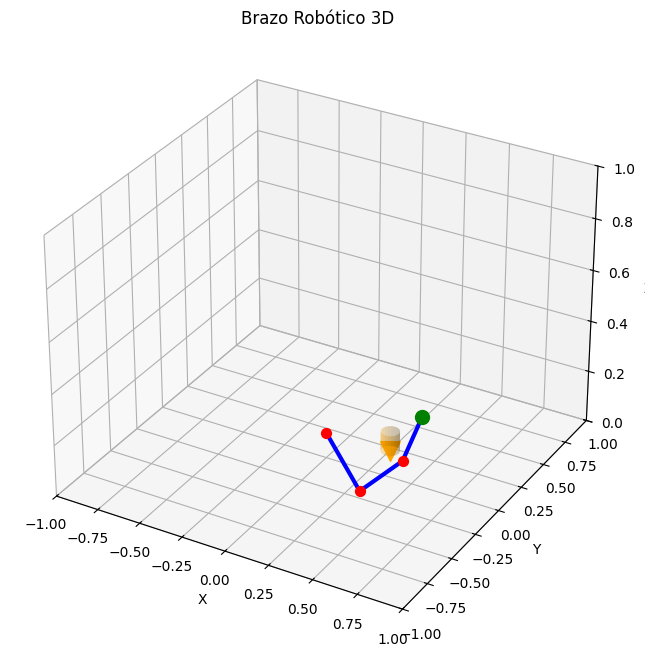

Episode 520, Avg Reward: 72.15, Success Rate: 34.0%, Avg Distance: 0.071, Difficulty: 0.20
Episode 540, Avg Reward: 77.57, Success Rate: 34.0%, Avg Distance: 0.070, Difficulty: 0.20
Episode 560, Avg Reward: 85.13, Success Rate: 35.0%, Avg Distance: 0.065, Difficulty: 0.20
Episode 580, Avg Reward: 88.16, Success Rate: 36.0%, Avg Distance: 0.065, Difficulty: 0.20
Episode 600, Avg Reward: 94.02, Success Rate: 32.0%, Avg Distance: 0.067, Difficulty: 0.20
Episode 620, Avg Reward: 102.44, Success Rate: 32.0%, Avg Distance: 0.065, Difficulty: 0.20
Episode 640, Avg Reward: 104.41, Success Rate: 35.0%, Avg Distance: 0.063, Difficulty: 0.20
Episode 660, Avg Reward: 109.81, Success Rate: 35.0%, Avg Distance: 0.063, Difficulty: 0.20
Episode 680, Avg Reward: 115.63, Success Rate: 36.0%, Avg Distance: 0.064, Difficulty: 0.20
Episode 700, Avg Reward: 116.33, Success Rate: 37.0%, Avg Distance: 0.063, Difficulty: 0.20
Episode 720, Avg Reward: 116.64, Success Rate: 40.0%, Avg Distance: 0.063, Difficulty

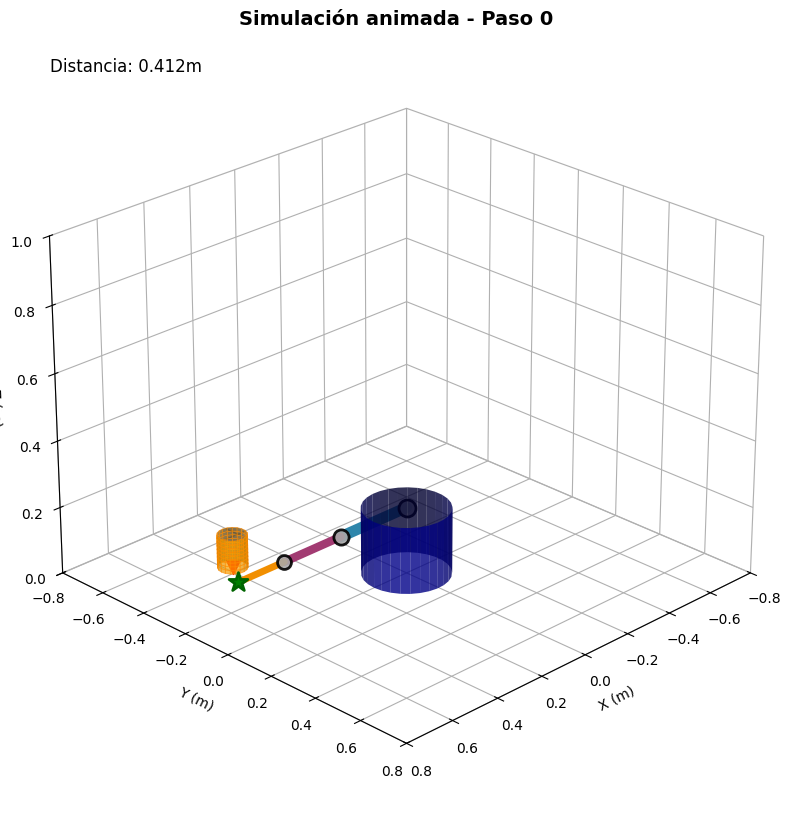

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


🎯 Episodio 1/10
  Vaso en: (0.05, 0.65, 0.03)


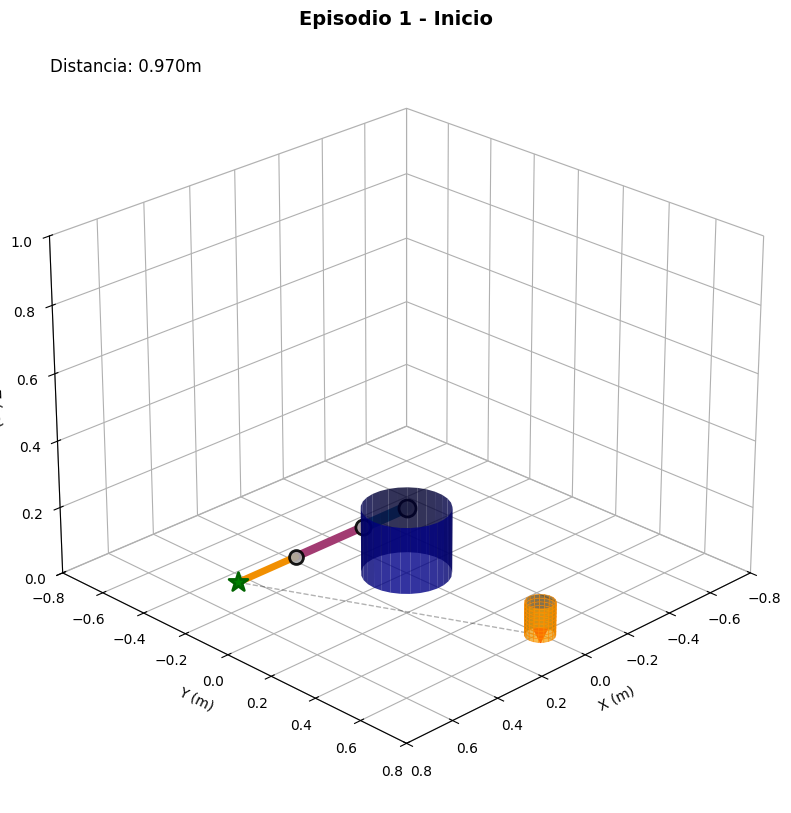

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

  ❌ Fallo. Distancia final: 0.336m


<Figure size 640x480 with 0 Axes>


📊 Tasa de éxito final: 20.0%


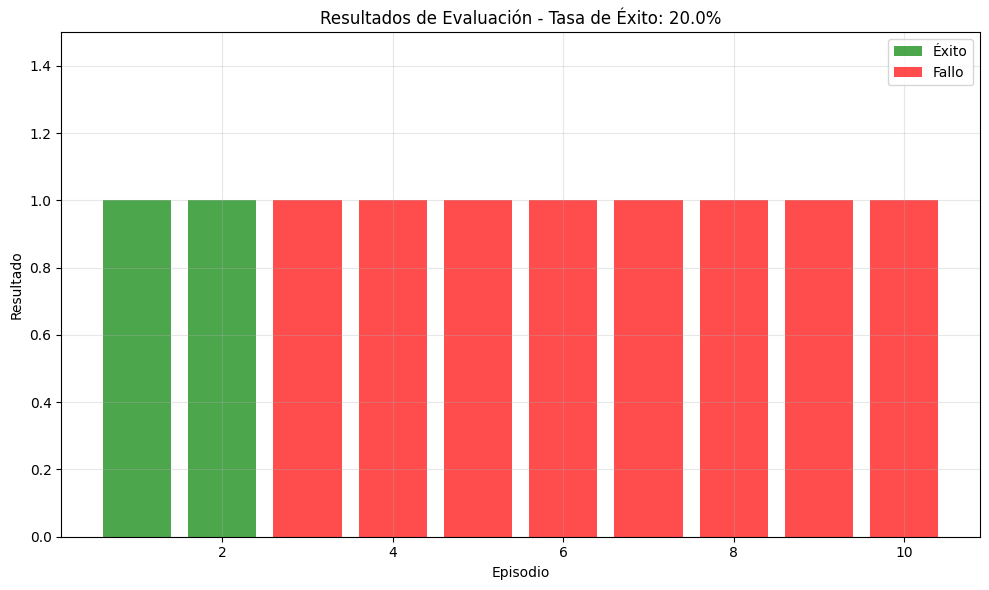

In [12]:
main()